# Notebook 4 — Conformal prediction

*Days 6-7 · turn predictions into intervals you can trust, then find where the trust runs out.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    obs = obs + rng.normal(0, 1, obs.shape) * (obs.mean(axis=1, keepdims=True) / snr[:, None])
    X = (obs @ B).astype(np.float32)
    return dict(X=X, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Intervals you can *trust*

Yesterday (Notebook 3) you turned each prediction of a star's **[Fe/H]** — its **metallicity**, the
amount of iron-group elements it holds relative to the Sun, measured in **dex** (a factor of 10 per
unit, because it's a base-10 log scale) — into a **prediction interval**: a range like
"[Fe/H] is between −0.55 and −0.25" that's *meant* to contain the true value. Then you checked it
and found the "90%" band wasn't honest everywhere — it sagged for **luminous giants and metal-poor
stars**.

Today we fix the *honesty* problem head-on. **Conformal prediction** takes *any* model's predictions
and wraps them in intervals that come with a real coverage **guarantee** — no Gaussian assumption,
no "trust the model." Then we probe exactly where that guarantee does, and doesn't, hold.

**Today's arc:**

1. **What conformal prediction is** — the one big idea, in pictures and one formula.
2. **The worked baseline** (the linear model) — five lines of numpy, and the team's Day-6 cross-check.
3. **Conformalize *your* model** — the same five lines, your predictions.
4. **Conformal vs. your native interval** — coverage *and* width, side by side.
5. **Does the guarantee hold *everywhere*?** — slice coverage across temperature, gravity, and
   metallicity. (This is the poster's headline.)
6. **Optional stretch** — two ways to fix the gap.
7. **Save** your intervals for the poster.

The familiar four-part rhythm still runs underneath — **explain → worked → your turn → explore** —
though today the *worked* baseline (§2) and *your turn* (§3) are deliberately the **same five lines**
on different predictions: that sameness *is* the lesson of "model-agnostic," and §5 is where you take
the wheel.

One nice thing about today: **you don't train anything.** Conformal works entirely from the
predictions you already saved — that's *why* it's "model-agnostic."

> Today's main reference is the **[*Gentle Introduction to Conformal Prediction*
> (Angelopoulos & Bates 2021)](https://arxiv.org/abs/2107.07511)**. The "[Fe/H] is hard in the
> sparse, weak-lined corners" story comes from **[Laroche & Speagle
> 2025](https://arxiv.org/abs/2404.07316)**, the paper behind our data.


## 0 · Load what you saved earlier

Everything we need is already on disk — **we do not refit any model today.** We load:

- the **point predictions** from Notebook 2 — saved on the *calibration* split and the *test* split,
  for both the **baseline** (`linear`, the shared model everyone built) and **your model** (`MODEL`);
- the **native interval** from Notebook 3 — your model's model-matched ± band, for the §4 comparison.
  (The plain linear baseline has no internal spread to read, so it never got a native band — that's
  fine, §4 compares *your* model's two bands.)

Two splits to keep straight (recap from Notebook 2):

- **calibration set** — a chunk we *deliberately* held out, never trained on. Today it does its one
  job: it *measures* how badly the model misses, so we can size the intervals honestly.
- **test set** — the untouched final exam. We only ever *report* numbers on it.

We also reload each test star's **Teff** (surface temperature), **log g** (surface gravity), and
**[Fe/H]** from the *same fixed split* (`seed=0`), because §5 slices coverage along those axes. The
seed makes the split identical to Notebooks 2 and 3 — the same stars, in the same order.

> If a load fails, you probably haven't run Notebooks 2 and 3 yet — do those first, or grab a TA.


In [2]:
# --- choose your model -------------------------------------------------------
MODEL    = "knn"       # <- set this to YOUR assigned model:  "knn" (A) / "rf" (B) / "nn" (C)
BASELINE = "linear"    # the shared baseline everyone cross-checks in section 2
TARGET   = 0.90        # we want 90% coverage
ALPHA    = 1.0 - TARGET # = 0.10  (alpha = the miss-rate we're willing to tolerate)

# --- a small safe loader: a clear message instead of a raw FileNotFoundError -----
def need_outputs(fname):
    path = os.path.join(OUTPUTS_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing outputs/{fname}.  Run Notebook 2 (predictions) and Notebook 3 "
            f"(native intervals) for model='{fname.split('_')[0]}' first — or ask a TA.")
    return load_outputs(fname)

# NB2 predictions (calibration + test) for the baseline and for your model.
pred_base  = need_outputs(f"{BASELINE}_preds.npz")
pred_model = need_outputs(f"{MODEL}_preds.npz")

# NB3 native (model-matched) intervals, for the comparison in section 4.
# (Only YOUR model has a native band — the plain linear baseline has no internal spread to read,
#  so Notebook 3 never built one for it.  That's fine: section 4 compares YOUR model's two bands.)
native_model = need_outputs(f"{MODEL}_native_intervals.npz")

# Conditioning axes for the TEST stars, from the SAME fixed split (seed=0) used in NB2/NB3.
# (We only need the test-split LABELS here, not the coefficients — and the split order depends only
#  on the number of stars and the seed, so the rows line up with NB2/NB3's saved predictions.)
X, y, meta = load_data()
sp = train_cal_test_split(X, y, seed=0)
teff_test = sp["y_test"]["Teff"].to_numpy()    # surface temperature [K]
logg_test = sp["y_test"]["logg"].to_numpy()    # surface gravity (low = luminous giant)
feh_test  = sp["y_test"]["FeH"].to_numpy()     # metallicity (low = metal-poor)

# Sanity: the saved test truths line up row-for-row with the freshly-loaded labels (same seed).
assert np.allclose(sp["y_test"]["FeH"].to_numpy(), pred_model["y_test_true"]), \
    "row-order mismatch — did NB2 split with seed=0 AFTER normalize_by_g?"

print(f"baseline = '{BASELINE}',  your model = '{MODEL}',  target coverage = {TARGET:.0%}")
print(f"calibration stars: {pred_model['y_cal_true'].size:,}    test stars: {pred_model['y_test_true'].size:,}")

Loaded xp_apogee_real.npz: REAL (Gaia XP x APOGEE)  —  30,000 stars (subsampled from 263,722; pass n=None for all), 110 coefficients.
baseline = 'linear',  your model = 'knn',  target coverage = 90%
calibration stars: 6,000    test stars: 6,000


*Everything we need is already saved — conformal works from predictions plus held-out truths, no retraining.*

## 1 · What conformal prediction *is*

**The problem.** You can *call* something a "90% interval," but did you ever *check* that the truth
lands inside 90% of the time? Usually the width came from assumptions — Gaussian noise, a trusted
model — that may be wrong. Conformal prediction lets you **stop hoping and start guaranteeing.**

**The one big idea.** Take *any* model you already have — linear, KNN, random forest, neural net, it
doesn't matter — and use a chunk of labeled data it never trained on (the **calibration set** — this
is *exactly* why Notebook 2 carved out a separate cal split) to **measure** how badly it actually
misses. Then use those measured misses to size the intervals on new stars. You let the data tell you
how big the error bars must be, instead of trusting a formula.

Here is the whole recipe, in four steps and one new symbol:

- **Nonconformity score.** For each calibration star, the absolute residual

  $$s_i = \lvert\, y_i - \hat{y}_i \,\rvert$$

  — literally "how wrong was the model here," in dex. Big score = badly wrong. (Why "nonconformity"?
  Because a big residual means that star *didn't conform* to the model's expectation.) For regression
  this is the standard, simplest choice.

- **The calibration quantile $\hat{q}$.** Pile up the calibration scores, sort them, and take the
  value that $(1-\alpha)$ of them fall at or below — for 90%, roughly the 90th percentile of the
  absolute errors. The logic is plain: 90% of the time the model's error was $\le \hat q$, so a band
  of $\pm\hat q$ should catch the truth about 90% of the time on *new* stars too. Note $\hat q$ is in
  the **units of $y$** (dex of [Fe/H]) — it's a *half-width*, **not** a probability.

- **The interval.** For every test star: $[\hat{y}-\hat{q},\; \hat{y}+\hat{q}]$. One number, learned
  from held-out data, turns points into guaranteed intervals.

- **Verify.** Measure the empirical coverage on the test set and check it lands near 90%.

**Why it works — exchangeability.** The *only* assumption is that the calibration stars and a new
test star are **exchangeable** — drawn from the same pool, in no special order — so a new star's
error is statistically just one more calibration error. That ranking argument is *all* the proof
needs. No bell curve, no "trust the model" — that's why conformal is **distribution-free** (it
assumes nothing about the shape of the error distribution) and **model-agnostic** (it doesn't care
which model made the predictions).

**The guarantee, stated honestly.** Under exchangeability, with $n$ calibration stars,

$$1-\alpha \;\le\; P\!\left(y_\text{test} \in [\hat y - \hat q,\, \hat y + \hat q]\right) \;\le\; 1-\alpha + \tfrac{1}{n+1}.$$

Coverage is **at least** 90%, and at most a hair above. **But this probability is *marginal*** —
averaged over *all* stars — **not** a per-star or per-region promise. (Hold that thought; it's the
whole §5 story.)

**Four traps to side-step:**

1. Conformal does **not** need Gaussian errors — only exchangeability.
2. The 90% guarantee is **on average**, not "every star / every region."
3. You **must** use the held-out **calibration** residuals — *not* training residuals (those look
   artificially small, so you'd under-cover).
4. Conformal makes your *uncertainty honest*; it does **not** make a bad model accurate.

> The exact quantile formula and the coverage bound are in the
> **[*Gentle Introduction* (Angelopoulos & Bates)](https://arxiv.org/abs/2107.07511)**. The
> *marginal vs. conditional* distinction (§5's punchline) is the same one you met in Notebook 3.


### A tiny worked-by-hand example (the one formula students fumble)

Say your calibration set had just **9 stars**, with these absolute [Fe/H] errors (dex):

$$0.05,\; 0.08,\; 0.10,\; 0.12,\; 0.15,\; 0.18,\; 0.22,\; 0.30,\; 0.45.$$

You want 90%, so $\alpha = 0.10$. The **finite-sample rule** says: take the score at rank
$\lceil (n+1)(1-\alpha)\rceil = \lceil 10 \times 0.90\rceil = 9$ — the **9th smallest = 0.45 dex**.
So $\hat q = 0.45$, and a star predicted at [Fe/H] $= -0.30$ gets the interval $[-0.75,\,+0.15]$.

**Why the "+1" and the ceiling?** With only a handful of points, to be *safe* at 90% you must reach
up toward the *biggest* error you saw; the "+1"/ceiling is a small-sample correction that keeps the
guarantee **exact**. With thousands of calibration stars (our case) it barely moves the answer — but
get the formula right. In code we simply **sort** the calibration errors and take the **$k$-th
smallest**, with $k = \lceil (n+1)(1-\alpha)\rceil$ — exactly the rank you just computed by hand.
You'll see this in the worked code next.


## 2 · Split conformal on the baseline — the Day-6 cross-check

Now we run the full recipe on the **baseline (`linear`)** predictions, end to end, in five lines.

**This is the team's Day-6 cross-check.** All three of you run this *identical* baseline example, and
you should get the *same* $\hat q$ and the *same* marginal coverage — the split is seeded and the
linear model is deterministic, so there's nothing left to disagree about. If your numbers don't
match, something upstream differs (a stale `outputs/` file, a different data version) — reconcile it
before moving on.

The four named steps: **(1)** scores on the calibration set, **(2)** the $(1-\alpha)$ quantile
$\hat q$ *with* the rank correction, **(3)** constant-width intervals on test, **(4)** verify the
marginal coverage lands on target.


In [3]:
# Split conformal, by hand, on the BASELINE predictions (pure numpy — no sklearn, no MAPIE).
y_cal_true  = pred_base["y_cal_true"]
y_cal_pred  = pred_base["y_cal_pred"]
y_test_true = pred_base["y_test_true"]
y_test_pred = pred_base["y_test_pred"]

# 1. Nonconformity scores on the CALIBRATION set = absolute residuals.
scores = np.abs(y_cal_true - y_cal_pred)
n = scores.size

# 2. The (1 - alpha) calibration quantile = the k-th SMALLEST score (the finite-sample rank
#    correction; plain averaging/interpolation would slightly under-cover).
k    = int(np.ceil((n + 1) * (1 - ALPHA)))        # the rank, 1-indexed (= 9 in the by-hand example)
qhat = np.sort(scores)[min(k, n) - 1]             # the k-th smallest error; min(k, n) clamps tiny n

# 3. Constant-width intervals on the TEST set:  y_pred +/- qhat.
lower_base = y_test_pred - qhat
upper_base = y_test_pred + qhat

# 4. Verify MARGINAL coverage (the fraction of test truths inside the band).
cov_base = empirical_coverage(y_test_true, lower_base, upper_base)
print(f"baseline qhat            = {qhat:.3f} dex   (the half-width of EVERY interval)")
print(f"baseline marginal coverage = {cov_base:.1%}   (target = {TARGET:.0%})")
print(f"baseline median width    = {np.median(upper_base - lower_base):.3f} dex")

baseline qhat            = 0.309 dex   (the half-width of EVERY interval)
baseline marginal coverage = 89.6%   (target = 90%)
baseline median width    = 0.618 dex


*Five lines of numpy turn point predictions into intervals whose **marginal** coverage lands right on the 90% target — and $\hat q$ is just the held-out 90th-percentile absolute error.*

### What just happened — and one edge case

In words: $\hat q$ is the value where "90% of the time the baseline's [Fe/H] error was no larger than
this," so a band of $\pm\hat q$ catches the truth about 90% of the time on fresh stars — and it did
(the printed coverage sits right around 90%).

**Day-6 reconciliation prompt:** compare your $\hat q$ and coverage with your teammates'. On the
baseline they should match *to the digit*. Do they?

**The clamp / edge case (a curiosity hook).** If you shrank the calibration set so small that
$k = \lceil (n+1)(1-\alpha)\rceil$ exceeded $n$ — fewer than 9 stars at 90% — there would be no
"$k$-th smallest", and the guarantee formally asks for $\hat q = +\infty$, an interval covering
everything. The `min(k, n)` clamp falls back to the largest error you actually saw. With thousands of
calibration stars it never triggers — but it's a good thing to *try* in the Explore section.

This baseline band is honest *on average*. Hold that thought for §5.


## 3 · Conformalize *your* model

Now do the **exact same thing** on your model's saved predictions (`MODEL`). The recipe doesn't
change — *that is the entire point of "model-agnostic."* Same target (90%), same four steps. The only
things that differ are which predictions go in, and therefore the numbers that come out.

What to look for: marginal coverage should again land near 90%, and $\hat q$ should be **smaller**
than the baseline's if your model fits [Fe/H] more accurately (a better model misses by less, so it
earns a tighter band).


In [4]:
# Your turn: conformalize YOUR model. This is the SAME five-step recipe as section 2 — it already
# runs for MODEL="knn". Run it as-is and read the numbers, then do the two small tasks at the bottom.

yc_true = pred_model["y_cal_true"];  yc_pred = pred_model["y_cal_pred"]
yt_true = pred_model["y_test_true"]; yt_pred = pred_model["y_test_pred"]

# 1. Nonconformity scores on the calibration set = absolute residuals.
scores_m = np.abs(yc_true - yc_pred)
n_m = scores_m.size

# 2. The (1 - alpha) quantile = the k-th smallest calibration error (same rank rule as section 2).
k_m    = int(np.ceil((n_m + 1) * (1 - ALPHA)))
qhat_m = np.sort(scores_m)[min(k_m, n_m) - 1]

# 3. Constant-width intervals on the test set:  prediction +/- qhat.
lower_model = yt_pred - qhat_m
upper_model = yt_pred + qhat_m

# 4. Check marginal coverage — look for a number close to 90%.
cov_model = empirical_coverage(yt_true, lower_model, upper_model)
print(f"{MODEL}: qhat = {qhat_m:.3f} dex,  marginal coverage = {cov_model:.1%}  (target {TARGET:.0%})")
print(f"{MODEL}: median interval width = {np.median(upper_model - lower_model):.3f} dex")
print(f"(the baseline's qhat from section 2 was {qhat:.3f} dex — is yours smaller?)")

# <- your turn (1): a more accurate model misses by less, so it earns a SMALLER qhat (a tighter band).
#                   Did yours come in below the baseline's above? Jot down why that makes sense.
# <- your turn (2): change TARGET near the top of the notebook (e.g. to 0.95) and re-run from there.
#                   Predict first — should the band get wider or narrower? — then check.

knn: qhat = 0.300 dex,  marginal coverage = 91.3%  (target 90%)
knn: median interval width = 0.600 dex
(the baseline's qhat from section 2 was 0.309 dex — is yours smaller?)


*The same five lines conformalize **any** model — your band lands near 90% coverage too, and its half-width $\hat q$ shrinks as your model gets more accurate.*

## 4 · Conformal vs. your native interval

In Notebook 3 you built a **native** interval — a band whose width came from *your model's own
internals* (KNN's neighbour scatter, RF's tree spread, or the NN ensemble's disagreement). That band
**adapts** its width per star (wider where the model feels unsure), which is appealing — but its
width came from a *Gaussian-ish* $\pm k\sigma$ picture that nobody checked, so its overall coverage
can drift off-target.

The conformal band you just built is a *constant* width, but that width came from a
**distribution-free quantile** of the actual held-out errors — so its marginal coverage is *pinned*
to ~90% by construction.

We compare the two on **two axes at once**, because neither alone is enough:

- **Coverage** — is the 90% promise kept? (An interval from $-\infty$ to $+\infty$ "covers" 100% and
  is useless, so coverage alone can never win.)
- **Sharpness = median width** — narrower is better, *but only at matched coverage*.

You read them **together**. The honest comparison: the native band may be narrower in places because
it adapts, but if it misses the coverage target, that narrowness was bought dishonestly. Conformal
trades the per-star adaptivity for a guarantee you can *state*.


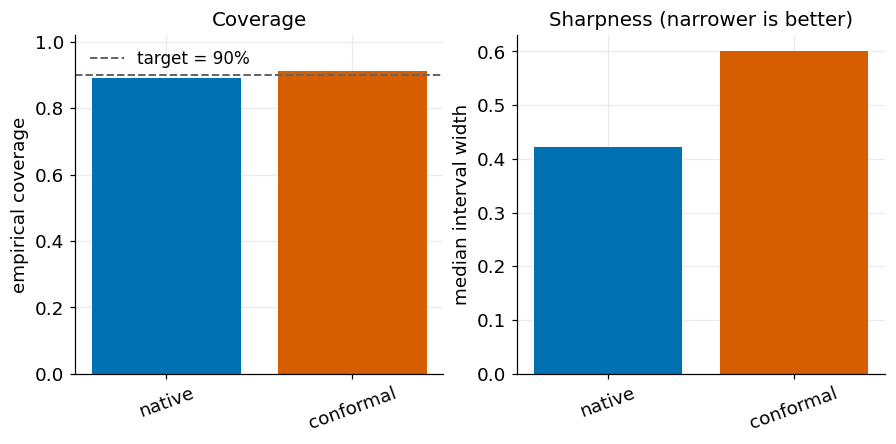

,coverage,median_width
method,,
native,0.889833,0.421371
conformal,0.913333,0.600491


In [5]:
# Put Notebook 3's native band next to today's conformal band, for YOUR model.
# compare_intervals draws two panels (coverage | median width) and returns a summary table.
nat_lo, nat_hi = native_model["lower"], native_model["upper"]   # the adaptive band from NB3

summary = compare_intervals(
    yt_true,
    {"native":    (nat_lo, nat_hi),                 # NB3 model-matched adaptive band
     "conformal": (lower_model, upper_model)},      # NB4 split-conformal band   <- your turn: plug yours in
    target=TARGET,
)
savefig(f"{MODEL}_native_vs_conformal.png")
plt.show()
summary   # columns: coverage | median_width  (read BOTH together)

*Read **both** bars: conformal sits right on the 90% line; the native band's coverage drifts off it. Coverage and width only make sense together.*

## 5 · Does the guarantee hold *everywhere*?

Recall the catch from §1: the guarantee is **marginal** — right *on average*. Now the question that
matters for science: is it right *everywhere*?

**Conditional coverage** means coverage *within every slice* of the data, not just overall. We'll
slice the test stars three ways and ask, in each slice, "does the conformal band still catch 90%?"

- by **Teff** (temperature),
- by **log g** (surface gravity — *low* log g = a puffed-up **luminous giant**; *high* = a compact
  **dwarf**),
- by **[Fe/H]** (metallicity — *low* = **metal-poor**).

Why these axes? Because the physics makes [Fe/H] **harder to read in some places than others**, and
the errors there are bigger (the noise is **heteroscedastic** — its size changes across the data,
just like in Notebook 3):

- **Metal-poor stars** have only faint metal absorption lines, so the spectrum carries little [Fe/H]
  information — large, irreducible scatter.
- **Luminous giants** are the sparse, most-extrapolated corner of the training set — few neighbours,
  weak lines, the hardest regime. (This is the real Laroche & Speagle effect, baked into our data.)

A single constant-width conformal band, tuned to be right *on average*, then **over-covers the easy
stars and under-covers the hard ones** — even though its *marginal* number looks perfect.

**Don't take our word for it — let the plot show you.** `plot_reliability(..., feature=…)` bins the
test stars into 8 equal-count bins along whichever axis you pass, and plots **measured coverage per
bin** against the dashed 90% line. Bins on the line = honest there; bins sagging below = under-cover
there. (Equal-*count* bins, so marker spacing reflects star density, not even steps; a bin with fewer
than 5 stars is dropped.)

**This is the poster's headline.** Conformal gives a *real, distribution-free* guarantee — but it's a
*marginal* one, and "right on average" hides "wrong for giants and metal-poor stars." Naming that
gap, showing it across these three axes, and pointing at the fix **is** the science. It's a feature
of the project, not a failure to hide.

> The marginal-vs-conditional distinction is in the
> **[*Gentle Introduction*](https://arxiv.org/abs/2107.07511)**; the physics of *where* [Fe/H] is
> hard is **[Laroche & Speagle 2025](https://arxiv.org/abs/2404.07316)**.


knn conformal coverage:  ALL = 91.3%   giants (log g < 3.5) = 88.5%   dwarfs (log g >= 3.5) = 97.1%


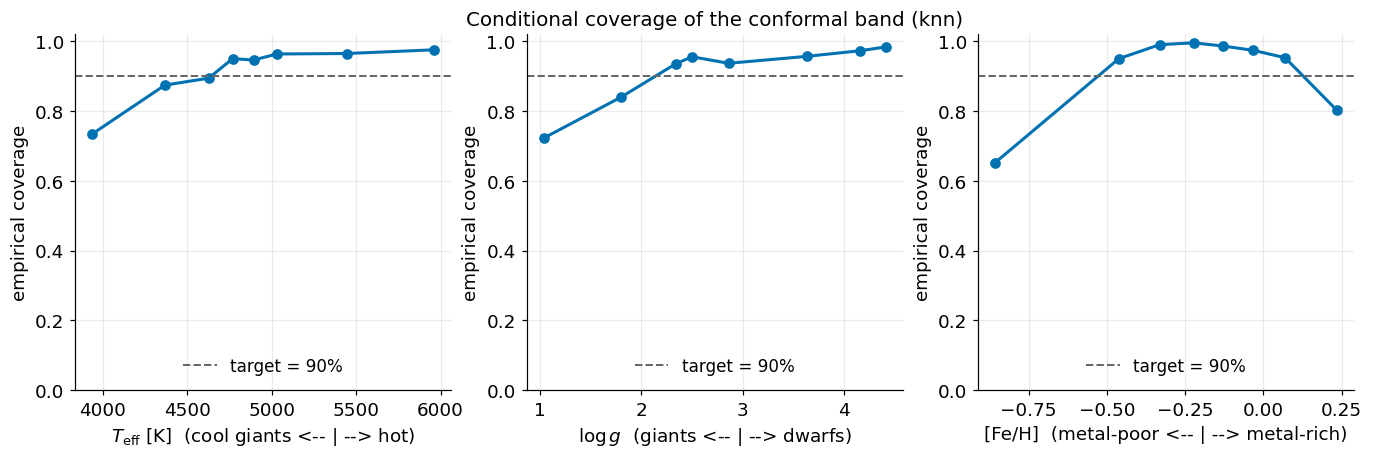

In [6]:
# A blunt first cut: split by gravity into luminous GIANTS (low log g) vs DWARFS (high log g),
# and read the conformal coverage in each.  (log g ~ 3.5 is roughly the giant/dwarf divide.)
GSPLIT = 3.5
giants = logg_test <  GSPLIT
dwarfs = logg_test >= GSPLIT

cov_all    = empirical_coverage(yt_true,          lower_model,          upper_model)
cov_giant  = empirical_coverage(yt_true[giants],  lower_model[giants],  upper_model[giants])
cov_dwarf  = empirical_coverage(yt_true[dwarfs],  lower_model[dwarfs],  upper_model[dwarfs])
print(f"{MODEL} conformal coverage:  ALL = {cov_all:.1%}   "
      f"giants (log g < {GSPLIT}) = {cov_giant:.1%}   dwarfs (log g >= {GSPLIT}) = {cov_dwarf:.1%}")

# Now the real diagnostic: coverage in 8 equal-count bins along THREE axes vs the 90% target.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=teff_test, feature_name=r"$T_\mathrm{eff}$ [K]  (cool giants <-- | --> hot)",
                 ax=axes[0])
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)",
                 ax=axes[1])
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <-- | --> metal-rich)",
                 ax=axes[2])
axes[1].set_title(f"Conditional coverage of the conformal band ({MODEL})")
savefig(f"{MODEL}_conditional_coverage.png")
plt.show()

*Marginal coverage is ~90%, but sliced by gravity, metallicity, or temperature the **luminous giants** and **metal-poor** bins dip below the line — the conformal guarantee is honest on average, not everywhere.*

In [7]:
# Explore (pick one or two — there's no single right answer):
#
# (1) Push the gravity split toward the luminous giants. How low does giant coverage fall?
GSPLIT_TRY = 2.5    # <- try 2.0, 2.5, 3.0  (lower = only the most luminous giants)
giants_try = logg_test < GSPLIT_TRY
print(f"giants (log g < {GSPLIT_TRY}) coverage = "
      f"{empirical_coverage(yt_true[giants_try], lower_model[giants_try], upper_model[giants_try]):.1%}  "
      f"(n = {giants_try.sum()})")
#
# (2) Slice by [Fe/H] instead. Where do the metal-poor stars land?
#     Hint: feh_test < np.quantile(feh_test, 0.2)  picks the most metal-poor fifth.
#
# (3) Shrink the calibration set and re-run section 3. How few cal stars before qhat gets noisy?
#     Hint: subsample with idx = np.random.default_rng(0).choice(yc_true.size, size=200, replace=False)
#           then recompute scores on yc_true[idx], yc_pred[idx]. (Recall the section-2 edge case.)

giants (log g < 2.5) coverage = 85.3%  (n = 2661)


## 6 · Optional stretch — fixing the conditional gap

Two standard upgrades restore *conditional* coverage. Both are **individual stretch**, not required.

- **Mondrian (group-conditional) conformal** — the easy, numpy-only one. Split the stars into groups
  (say, a "giant" gravity bin and a "dwarf" bin), and run the *whole* conformal recipe **separately
  inside each group**, so each gets its **own** $\hat q$. The giants' band is then sized by *giants'*
  errors → coverage holds in each bin. It directly targets our failure mode. (Honest caveat: it
  "fixes" the gap *by construction* on the bins you chose — it doesn't create information the spectrum
  lacks; it just stops pretending the giant band is as tight as the dwarf band.)

- **CQR (Conformalized Quantile Regression)** — the heavier one, a *pointer only*. Instead of a
  constant $\pm\hat q$, start from a model that predicts a *low* and a *high* quantile (so the raw
  band is already wide where the data are noisy), then conformally nudge those two edges on the
  calibration set. The width then **adapts per star** — wide for giants, tight for dwarfs — fixing
  coverage *and* sharpness. It needs a quantile regressor (e.g.
  `GradientBoostingRegressor(loss="quantile")`), so it's more code; we point at it rather than build
  it.

> **[CQR — Romano, Patterson & Candès 2019](https://arxiv.org/abs/1905.03222)** ·
> **[MAPIE CQR tutorial](https://mapie.readthedocs.io/en/stable/examples_regression/4-tutorials/plot_cqr_tutorial.html)** ·
> **[Awesome Conformal Prediction](https://github.com/valeman/awesome-conformal-prediction)** (Mondrian
> & group-conditional methods). scikit-learn has no built-in conformal regressor, so these stay
> *reference*; our shipped notebook is numpy-only.


single-qhat conformal:  giants = 88.5%   dwarfs = 97.1%
Mondrian (per-group)  :  marginal = 90.8%


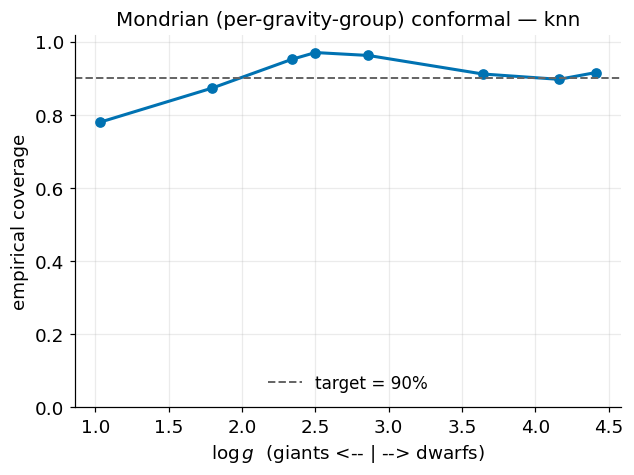

In [8]:
# OPTIONAL STRETCH — Mondrian (group-conditional) conformal, numpy only.  Skip if short on time.
# Idea: run the section-3 recipe SEPARATELY inside a GIANT group and a DWARF group, so each gets
# its own qhat.  We need the calibration stars' log g to assign them to groups (same seed=0 split).
logg_cal = sp["y_cal"]["logg"].to_numpy()
GROUP_EDGE = 3.5     # the giant / dwarf divide in log g

def conformal_qhat(scores, alpha):
    nloc = scores.size
    k = int(np.ceil((nloc + 1) * (1 - alpha)))    # the same k-th-smallest rule as section 2
    return np.sort(scores)[min(k, nloc) - 1]

lower_mond = np.empty_like(yt_pred)
upper_mond = np.empty_like(yt_pred)
for sel_cal, sel_test in [(logg_cal <  GROUP_EDGE, logg_test <  GROUP_EDGE),   # giants
                          (logg_cal >= GROUP_EDGE, logg_test >= GROUP_EDGE)]:  # dwarfs
    s = np.abs(yc_true[sel_cal] - yc_pred[sel_cal])     # scores within THIS group only
    q = conformal_qhat(s, ALPHA)                         # this group's own qhat
    lower_mond[sel_test] = yt_pred[sel_test] - q
    upper_mond[sel_test] = yt_pred[sel_test] + q

print(f"single-qhat conformal:  giants = "
      f"{empirical_coverage(yt_true[logg_test < GROUP_EDGE], lower_model[logg_test < GROUP_EDGE], upper_model[logg_test < GROUP_EDGE]):.1%}"
      f"   dwarfs = "
      f"{empirical_coverage(yt_true[logg_test >= GROUP_EDGE], lower_model[logg_test >= GROUP_EDGE], upper_model[logg_test >= GROUP_EDGE]):.1%}")
print(f"Mondrian (per-group)  :  marginal = {empirical_coverage(yt_true, lower_mond, upper_mond):.1%}")

# Did the giant dip shrink?  Compare the conditional picture.
ax = plot_reliability(yt_true, lower_mond, upper_mond, target=TARGET,
                      feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)")
ax.set_title(f"Mondrian (per-gravity-group) conformal — {MODEL}")
plt.show()

*Give the giants their **own** $\hat q$ and the conditional dip shrinks — group-conditional conformal trades one band for a per-group band.*

## 7 · Save your conformal intervals

Save your model's conformal intervals in the **locked schema**, so the poster figures (regenerated
later from `outputs/`) can use them: `outputs/{MODEL}_conformal_intervals.npz` with keys
`y_test_true, lower, upper, target`.

These join `{MODEL}_preds.npz` (Notebook 2) and `{MODEL}_native_intervals.npz` (Notebook 3) — the
full evidence trail for the poster's results and limitations sections, with **no new notebook
needed** to make the final figures. Your two saved figures —
`figures/{MODEL}_native_vs_conformal.png` and `figures/{MODEL}_conditional_coverage.png` — are the
poster's two punchlines.


In [9]:
save_outputs(
    f"{MODEL}_conformal_intervals.npz",
    y_test_true=yt_true,
    lower=lower_model,
    upper=upper_model,
    target=TARGET,             # = 0.90, the nominal coverage we built for
)
# Reload and confirm the schema NB4's poster figures expect.
chk = load_outputs(f"{MODEL}_conformal_intervals.npz")
print(f"saved outputs/{MODEL}_conformal_intervals.npz")
print("keys:", sorted(chk.keys()),
      "| coverage:", f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}")

saved outputs/knn_conformal_intervals.npz
keys: ['lower', 'target', 'upper', 'y_test_true'] | coverage: 91.3%


*Saved in the shared schema — Notebook 2 preds → Notebook 3 native → Notebook 4 conformal, the full evidence trail for the poster.*

## Wrap-up — what to put on the poster

Three sentences of takeaway:

1. **Conformal prediction** wraps *any* model's predictions in intervals with a distribution-free,
   finite-sample **marginal** coverage guarantee, learned from a held-out calibration set — five
   lines of numpy, no Gaussian assumption.
2. It **pinned marginal coverage to ~90%** that your Notebook 3 native band had drifted off — the
   guarantee is the win.
3. **But the guarantee is *marginal*.** Sliced by gravity, metallicity, or temperature, the
   **luminous giants and metal-poor stars are under-covered** — the honest limitation that is your
   poster's headline.

**The bigger picture — label transfer at scale.** In Notebook 2's last experiment you watched
accuracy improve as you fed the model more of the ~260,000 labelled stars. That same trained pipeline
is what you would point at the **~220 million** stars that have a *Gaia* XP spectrum but **no**
spectroscopic label — estimating metallicities across the Milky Way where we otherwise have none. The
conformal intervals are what make those estimates *trustworthy at scale*; your conditional-coverage
finding is the caveat you would ship right alongside them.

**Bridge to the comms phase.** Your two saved figures (`native_vs_conformal`,
`conditional_coverage`) plus the `compare_intervals` table are the backbone of the **results** and
**limitations** sections.

**One reflective prompt.** If you had to *ship* metallicities for 200 million Gaia stars tomorrow,
would you ship the single conformal band as-is, or the Mondrian per-group band — and what would you
tell a user about the giants?

The conditional gap isn't a bug you introduced — it mirrors a real open problem in the field
(**[Laroche & Speagle 2025](https://arxiv.org/abs/2404.07316)**, the data's source paper). You've
reproduced and *named* it. That's science.
